In [ ]:
# Standard scientific Python imports
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

# Import datasets, classifiers and performance metrics
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split, KFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix


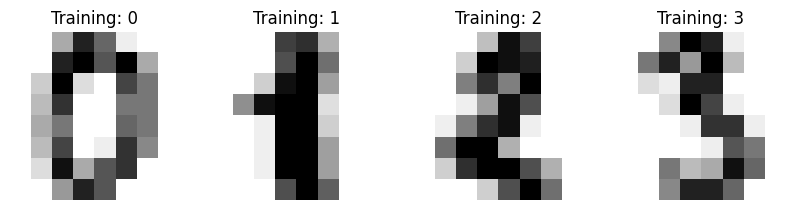

In [4]:
digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))

for ax, image, label in zip(axes, digits.images, digits.target): 
  ax.set_axis_off()
  ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
  ax.set_title("Training: %i" % label)

array([0, 1, 2, ..., 8, 9, 8])

In [5]:
X_digits, y_digits = datasets.load_digits(return_X_y=True)
print(X_digits)
print(y_digits)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
[0 1 2 ... 8 9 8]


## 1  unica particion de datos genererada mediante train_test_split

In [ ]:
# Particionamiento de los datos
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.33, random_state=42)

# Definimos el modelo
clf = MLPClassifier(hidden_layer_sizes=(20,10), learning_rate_init=0.005, activation='logistic', early_stopping=True, shuffle=True, random_state=42, max_iter=200)

# Entrenamiento del modelo
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)



Accuracy: 0.9511784511784511


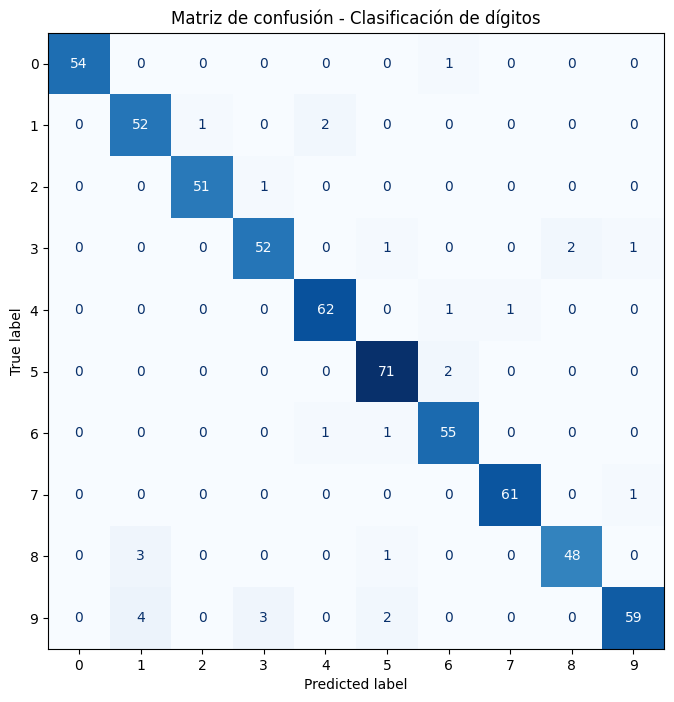

Accuracy: 0.9511784511784511


In [13]:
cm = confusion_matrix(y_test, y_pred, labels=digits.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax = ax, cmap="Blues", values_format="", colorbar=None)
ax.set_title("Matriz de confusión - Clasificación de dígitos")
plt.show()
print(f"Accuracy: {acc}")


## 5 particiones generadas mediante KFold

In [38]:
# Definimos el modelo
clf = MLPClassifier(hidden_layer_sizes=(20,10), learning_rate_init=0.005, activation='logistic', early_stopping=True, shuffle=True, random_state=42, max_iter=200)

kf = KFold(n_splits=5, random_state=42, shuffle=True)

ACC = []

for fold, (train_index, test_index) in enumerate(kf.split(X_digits)): 
    X_train, y_train = X_digits[train_index], y_digits[train_index]
    X_test, y_test = X_digits[test_index], y_digits[test_index]
    # Entrenamiento del modelo
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc_fold = accuracy_score(y_test, y_pred)
    ACC.append(acc_fold)
        
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")

# Creamos una tabla
table_data = []
for i in range(len(ACC)):
    table_data.append({"Fold": i+1, "Accuracy": ACC[i]})

table = tabulate(table_data, headers="keys", tablefmt="simple_grid", stralign="center", numalign='center')
print(table)

% de aciertos medios: 0.936564531104921
Varianza de la exactitud: 0.00015578009516099687
┌────────┬────────────┐
│  Fold  │  Accuracy  │
├────────┼────────────┤
│   1    │  0.941667  │
├────────┼────────────┤
│   2    │   0.925    │
├────────┼────────────┤
│   3    │  0.91922   │
├────────┼────────────┤
│   4    │  0.952646  │
├────────┼────────────┤
│   5    │  0.94429   │
└────────┴────────────┘


## 10 particiones generadas mediante KFold

In [ ]:
# Definimos el modelo
clf = MLPClassifier(hidden_layer_sizes=(20,10), learning_rate_init=0.005, activation='logistic', early_stopping=True, shuffle=True, random_state=42, max_iter=200)

kf = KFold(n_splits=10, random_state=42, shuffle=True)

ACC = []

for fold, (train_index, test_index) in enumerate(kf.split(X_digits)): 
    X_train, y_train = X_digits[train_index], y_digits[train_index]
    X_test, y_test = X_digits[test_index], y_digits[test_index]
    # Entrenamiento del modelo
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    acc_fold = accuracy_score(y_test, y_pred)
    ACC.append(acc_fold)
        
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")

# Creamos una tabla
table_data = []
for i in range(len(ACC)):
    table_data.append({"Fold": i+1, "Accuracy": ACC[i]})

table = tabulate(table_data, headers="keys", tablefmt="simple_grid", stralign="center", numalign='center')
print(table)

% de aciertos medios: 0.9432371198013655
Varianza de la exactitud: 0.00027166416986569336
┌────────┬────────────┐
│  Fold  │  Accuracy  │
├────────┼────────────┤
│   1    │    0.95    │
├────────┼────────────┤
│   2    │  0.961111  │
├────────┼────────────┤
│   3    │  0.961111  │
├────────┼────────────┤
│   4    │  0.916667  │
├────────┼────────────┤
│   5    │  0.927778  │
├────────┼────────────┤
│   6    │  0.938889  │
├────────┼────────────┤
│   7    │    0.95    │
├────────┼────────────┤
│   8    │  0.938547  │
├────────┼────────────┤
│   9    │  0.96648   │
├────────┼────────────┤
│   10   │  0.921788  │
└────────┴────────────┘


Con la varianza podemos ver cuanto flutua la estimacion de aciertos entre los diferentes fold. Es por eso que: 
* Si tenemos mas datos en cada evaluacion de test, la estimacion se basa en un conjunto mas representativo

## Conclusiones
Podemos ver que al utilizar un numero menor de particiones K=5
* El fold que obtenemos de test es mas grande, por lo tanto la estimacion del acierto tiene una menor varianza. 
* Sin embargo el fold de train es un poco mas chico, por lo tanto el modelo se entrena con menos datos

En cambio cuando utilizamos un numero mayor de particiones K=10
* El fold que obtenemos de test es menor, por lo tanto la estimacion del acierto en cada fold va a tener una mayor varianza
* El modelo se entrena con mas datos


